# Iris Clustering Project
KMeans and Hierarchical Clustering

## Objective
To apply KMeans and Hierarchical clustering on the Iris dataset, identify natural clusters, and evaluate the effectiveness of unsupervised learning techniques.

##  Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

##  Load Dataset

In [20]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


##  Preprocessing

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [22]:
df.shape

(150, 5)

In [23]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [24]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### insights
The Iris dataset contains 150 samples with 4 numerical features: sepal length, sepal width, petal length, and petal width. These features describe the physical characteristics of iris flowers. The dataset is clean, well-structured, and contains no missing values, making it suitable for clustering.

In [25]:
X = df.drop('species', axis=1)

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### insights
The species column was removed because clustering is an unsupervised learning technique.
Feature scaling was applied using StandardScaler to ensure all features contribute equally to the clustering process.

## Correlation heatmap

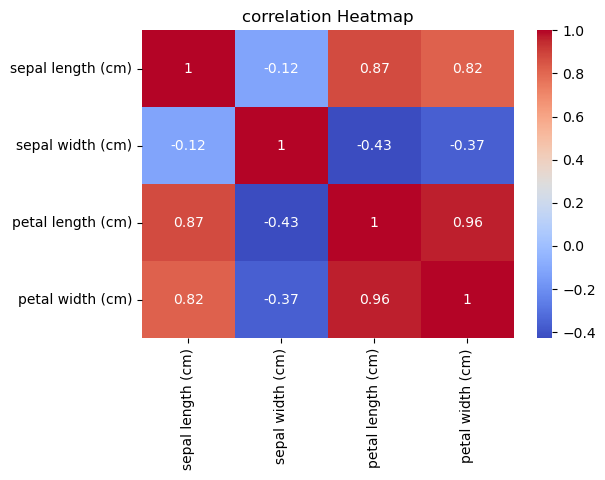

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(df.drop("species",axis=1).corr(),annot=True,cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

### insights
* Petal length and petal width
  they have a very strong positive correlation (~0.96).
  Both petal features are highly correlated with species (~0.95–0.96), meaning they are strong indicators of flower type.
* Sepal length shows moderate correlation with petal features.
* Sepal width has weak or negative correlations, indicating it contributes less to distinguishing clusters.

Conclusion:
Petal length and petal width are the most important features for clustering due to their strong relationships and clear separability.

##  Elbow Method

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

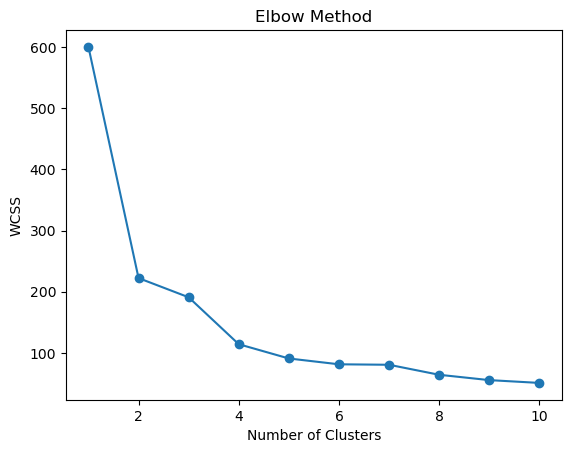

In [28]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

### insights
he Elbow Method was used to determine the optimal number of clusters. The WCSS (Within-Cluster Sum of Squares) decreases as the number of clusters increases. A clear “elbow” is observed at K = 3, where the rate of decrease slows down significantly.

Conclusion:
The optimal number of clusters for the Iris dataset is 3, which aligns with the natural grouping of the data.

##  KMeans Clustering

### How KMeans Works:

* Chooses K number of clusters
* Assigns data points to nearest centroid
* Updates centroid positions
* Repeats until convergence

### Why suitable for Iris:

* Dataset is small and well-structured
* Natural grouping (3 flower types)
* Works well with numeric features

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


##  Visualize KMeans

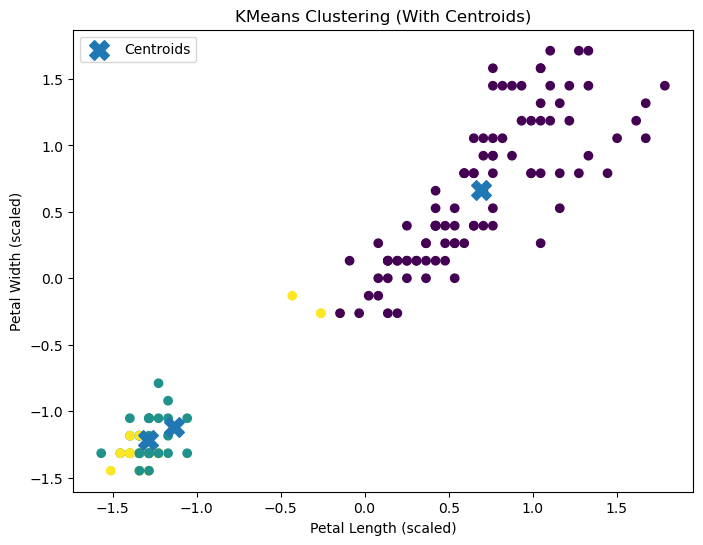

In [30]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

# Plot clusters
plt.scatter(
    X_scaled[:, 2],   # petal length (scaled)
    X_scaled[:, 3],   # petal width (scaled)
    c=kmeans_labels
)

# Plot centroids
plt.scatter(
    centers[:, 2],
    centers[:, 3],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('KMeans Clustering (With Centroids)')
plt.legend()
plt.show()

### insights
The scatter plot using petal length and petal width shows three clearly separated clusters. One cluster is completely distinct, while the other two have slight overlap.

Conclusion:
Petal features provide strong visual separation, confirming that clustering is effective.

##  Hierarchical Clustering

### How Hierarchical Clustering Works:

Builds clusters step-by-step
Two types:
* Agglomerative (bottom-up)
* Divisive (top-down)
Uses dendrogram to decide clusters

### Why suitable for Iris:

* No need to predefine clusters
* Shows relationships between points
* Good for small datasets

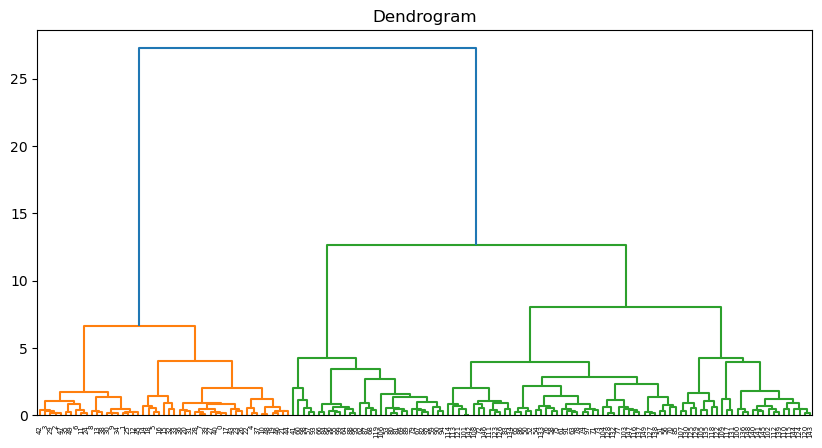

In [31]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

### insights
The dendrogram shows how data points are merged step-by-step. The vertical distance between merges represents dissimilarity.

* A large vertical gap suggests a good place to cut the tree.
* Cutting the dendrogram at an appropriate level results in 3 clusters.

In [32]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

df['HC_Cluster'] = hc_labels

##  Visualize Hierarchical

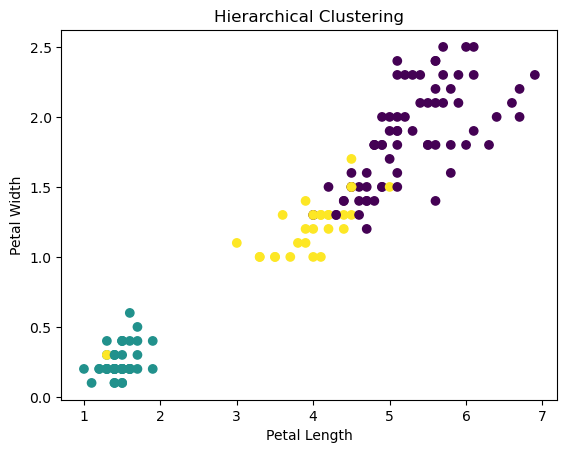

In [33]:
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=hc_labels)
plt.title('Hierarchical Clustering')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.show()

##  Conclusion
Both methods successfully grouped the dataset into 3 clusters.
The clustering results closely align with the actual species distribution, indicating that unsupervised learning can successfully uncover hidden patterns in structured datasets.

### insights
* KMeans and Hierarchical clustering both grouped the dataset into 3 clusters.
* KMeans is faster and efficient.
* Hierarchical clustering provides better visualization through dendrogram.
* Both methods perform well on the Iris dataset due to its clear structure.